In [1]:
import torch
import torch.nn as nn
import dataloader as dl
import torch.optim as SGD
import torch.nn.init as init
import matplotlib.pyplot as plt

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])


# Creating cnn Layers

In [2]:
conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
linear = nn.Linear(64*7*7, 10)

# weight initialization

In [3]:
init.kaiming_uniform_(conv1.weight, nonlinearity='relu')
init.kaiming_uniform_(conv2.weight, nonlinearity='relu')
init.kaiming_uniform_(linear.weight)

Parameter containing:
tensor([[ 0.0318, -0.0193,  0.0024,  ...,  0.0093,  0.0208, -0.0069],
        [-0.0094, -0.0018,  0.0175,  ...,  0.0290, -0.0223,  0.0399],
        [ 0.0248, -0.0078, -0.0197,  ...,  0.0110, -0.0318,  0.0056],
        ...,
        [-0.0425,  0.0125,  0.0060,  ..., -0.0112, -0.0082,  0.0189],
        [ 0.0234, -0.0125,  0.0091,  ..., -0.0377,  0.0165,  0.0266],
        [-0.0073,  0.0188,  0.0164,  ..., -0.0285, -0.0296,  0.0157]],
       requires_grad=True)

# Creating Cnn model

In [4]:
cnn = nn.Sequential(
    conv1,
    nn.ReLU(),  
    nn.MaxPool2d(kernel_size=2, stride=2),
    
    conv2,
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    
    nn.Flatten(),
    linear,
)

# Training the Cnn model

### Setting up the loss function and optimizer

In [5]:
learning_rate = 0.01
num_epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = SGD.SGD(cnn.parameters(), lr=learning_rate)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn.to(device)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=10, bias=True)
)

In [6]:

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    # TRAINING
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for data, target in dl.train_loader_nn:
        data = data.unsqueeze(1).to(device)  # unsqueeze to add channel dimension as cnn needs 4D input
        target = target.to(device)
        
        optimizer.zero_grad()
        output = cnn(data)
        loss = loss_function(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(output, 1)
        train_total += target.size(0)
        train_correct += (predicted == target).sum().item()
    
    # VALIDATION
    cnn.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data, target in dl.val_loader_nn:
            data = data.unsqueeze(1).to(device)  # unsqueeze to add channel dimension as cnn needs 4D input
            target = target.to(device)
                        
            output = cnn(data)
            loss = loss_function(output, target)
            
            val_loss += loss.item()
            _, predicted = torch.max(output, 1)
            val_total += target.size(0)
            val_correct += (predicted == target).sum().item()
    
    # Calculate averages
    train_loss = train_loss / len(dl.train_loader_nn)
    val_loss = val_loss / len(dl.val_loader_nn)
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Print progress
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

Epoch 1/20
  Train Loss: 0.5192 | Train Acc: 85.14%
  Val Loss: 0.3645 | Val Acc: 88.12%
Epoch 2/20
  Train Loss: 0.2251 | Train Acc: 93.37%
  Val Loss: 0.1959 | Val Acc: 94.42%
Epoch 3/20
  Train Loss: 0.1660 | Train Acc: 95.17%
  Val Loss: 0.1701 | Val Acc: 95.03%
Epoch 4/20
  Train Loss: 0.1325 | Train Acc: 96.22%
  Val Loss: 0.1351 | Val Acc: 96.07%
Epoch 5/20
  Train Loss: 0.1112 | Train Acc: 96.84%
  Val Loss: 0.1091 | Val Acc: 96.95%
Epoch 6/20
  Train Loss: 0.0973 | Train Acc: 97.21%
  Val Loss: 0.1000 | Val Acc: 97.20%
Epoch 7/20
  Train Loss: 0.0869 | Train Acc: 97.47%
  Val Loss: 0.0996 | Val Acc: 97.09%
Epoch 8/20
  Train Loss: 0.0787 | Train Acc: 97.68%
  Val Loss: 0.0895 | Val Acc: 97.47%
Epoch 9/20
  Train Loss: 0.0731 | Train Acc: 97.86%
  Val Loss: 0.0794 | Val Acc: 97.63%
Epoch 10/20
  Train Loss: 0.0674 | Train Acc: 98.02%
  Val Loss: 0.1022 | Val Acc: 96.78%
Epoch 11/20
  Train Loss: 0.0643 | Train Acc: 98.10%
  Val Loss: 0.0807 | Val Acc: 97.60%
Epoch 12/20
  Train

# Training and validation loss

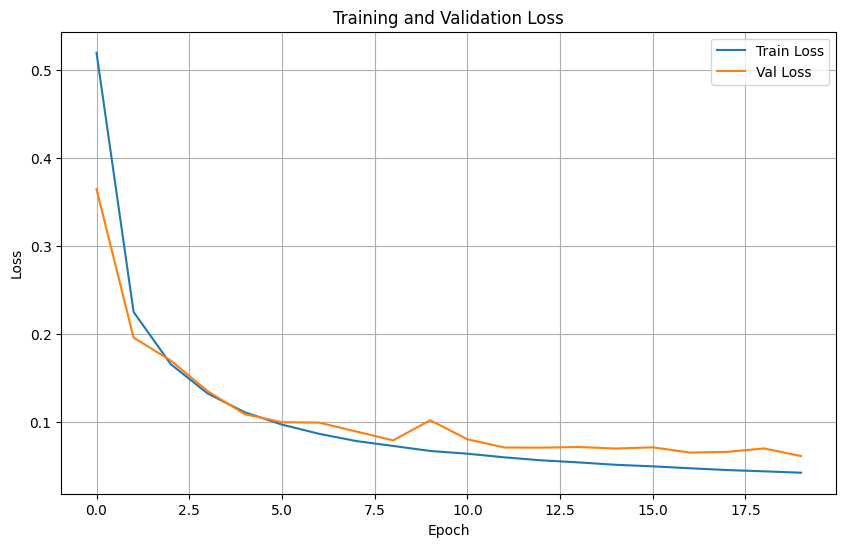

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Training and Validation accuracy

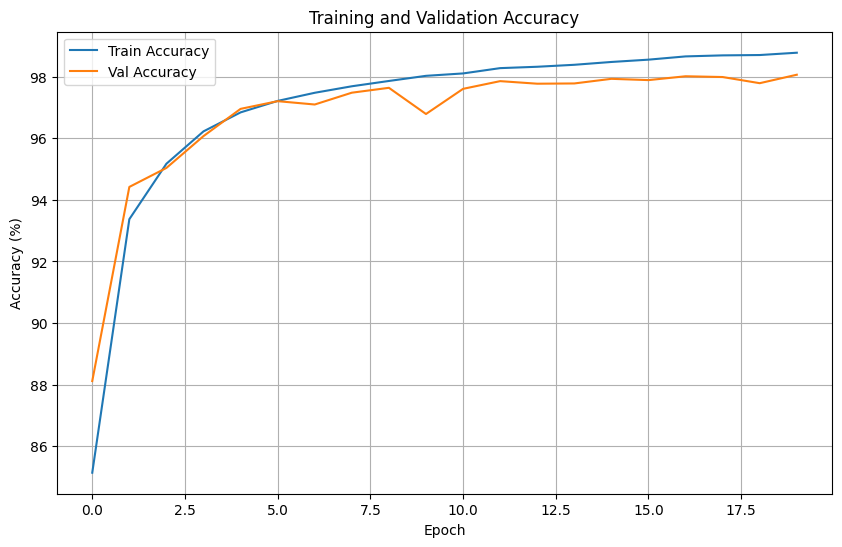

In [8]:

plt.figure(figsize=(10, 6))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Testing the Cnn model

In [9]:
test_acc_list = []

for data, target in dl.test_loader_nn:
    data = data.unsqueeze(1).to(device)
    target = target.to(device)
    
    output = cnn(data)
    _, predicted = torch.max(output, 1)
    
    test_total = target.size(0)
    test_correct = (predicted == target).sum().item()
    
    test_acc = 100 * test_correct / test_total
    test_acc_list.append(test_acc)
    
average_test_acc = sum(test_acc_list) / len(test_acc_list)

print(f'Average Test Accuracy over all batches: {average_test_acc:.2f}%')

Average Test Accuracy over all batches: 98.24%
